In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from google.colab import drive


# Cargar datos

In [12]:
file_id = "1dKXgfMS_q-hno4MdHKGvZIgm7tn2kOI6"
url = f"https://drive.google.com/uc?id={file_id}"
customers_data = pd.read_csv(url)

# Limpieza básica

In [13]:
# Eliminar duplicados
customers_data = customers_data.drop_duplicates()
# Porcentaje de datos nulos por columnas
null_data = (customers_data.isnull().sum() / len(customers_data)) * 100
print("Datos nulos")
print("\n", null_data)

Datos nulos

 Date                0.0
Day                 0.0
Month               0.0
Year                0.0
Customer_Age        0.0
Age_Group           0.0
Customer_Gender     0.0
Country             0.0
State               0.0
Product_Category    0.0
Sub_Category        0.0
Product             0.0
Order_Quantity      0.0
Unit_Cost           0.0
Unit_Price          0.0
Profit              0.0
Cost                0.0
Revenue             0.0
dtype: float64


# Validación y corrección de Revenue y Profit

In [14]:
# Revenue
customers_data['Revenue_Check'] = customers_data['Unit_Price'] * \
    customers_data['Order_Quantity']
customers_data.loc[customers_data['Revenue'] != customers_data['Revenue_Check'], 'Revenue'] = \
    customers_data['Revenue_Check']

# Profit
customers_data['Profit_Check'] = customers_data['Revenue'] - \
    customers_data['Cost']
customers_data.loc[customers_data['Profit'] != customers_data['Profit_Check'], 'Profit'] = \
    customers_data['Profit_Check']

# Crear margen de ganancia
customers_data['Profit_Margin'] = customers_data['Profit'] / \
    customers_data['Revenue']

# Transformación logarítmica (log1p)


In [15]:
cols_skewed = ["Order_Quantity", "Unit_Cost",
               "Unit_Price", "Profit", "Cost", "Revenue"]
for col in cols_skewed:
    customers_data[col + "_log"] = np.log1p(customers_data[col])

# Visualización de columnas con log1p







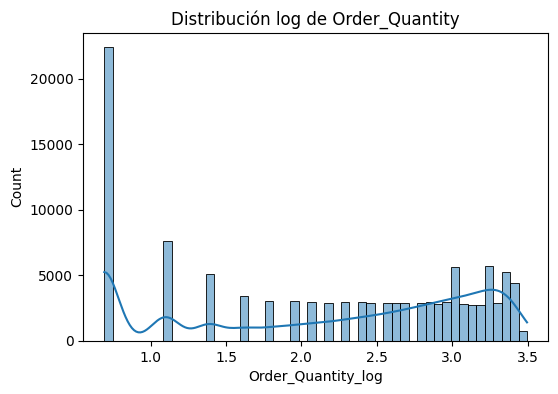

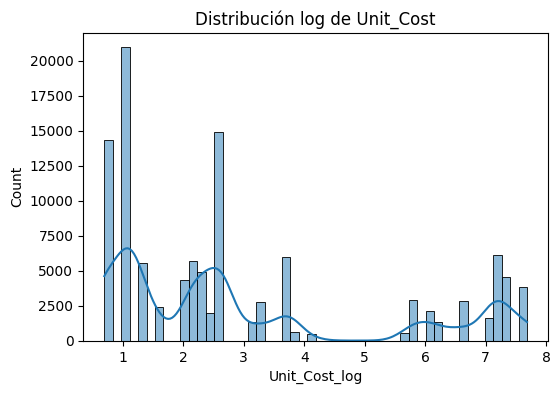

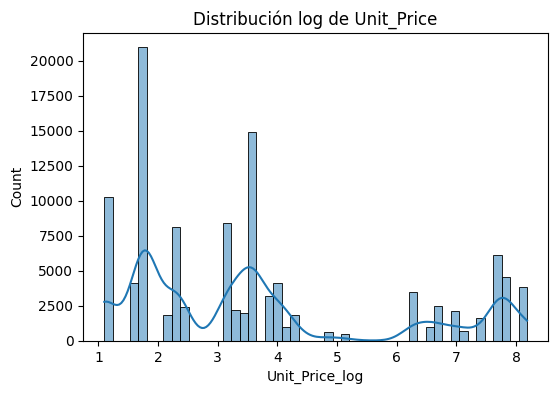

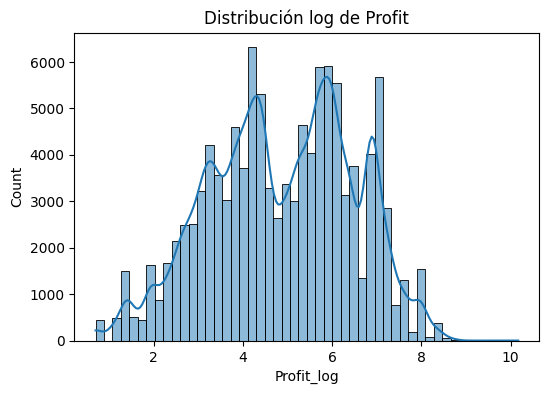

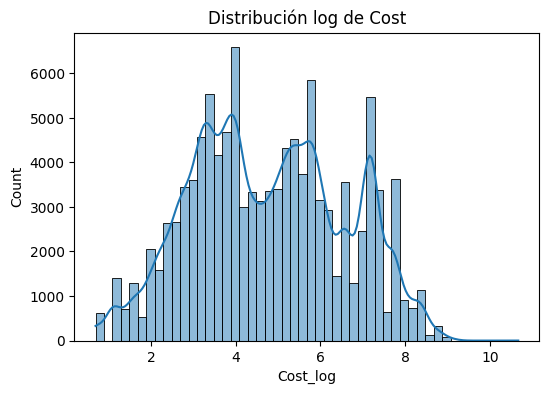

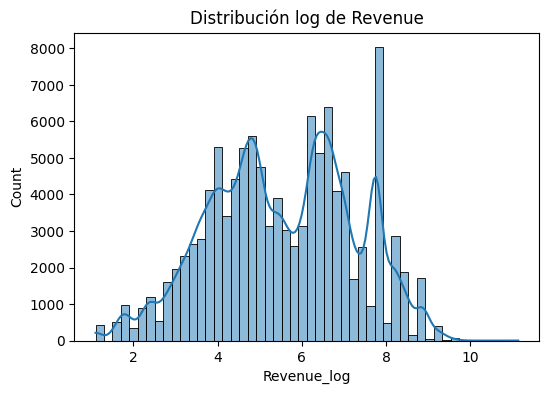

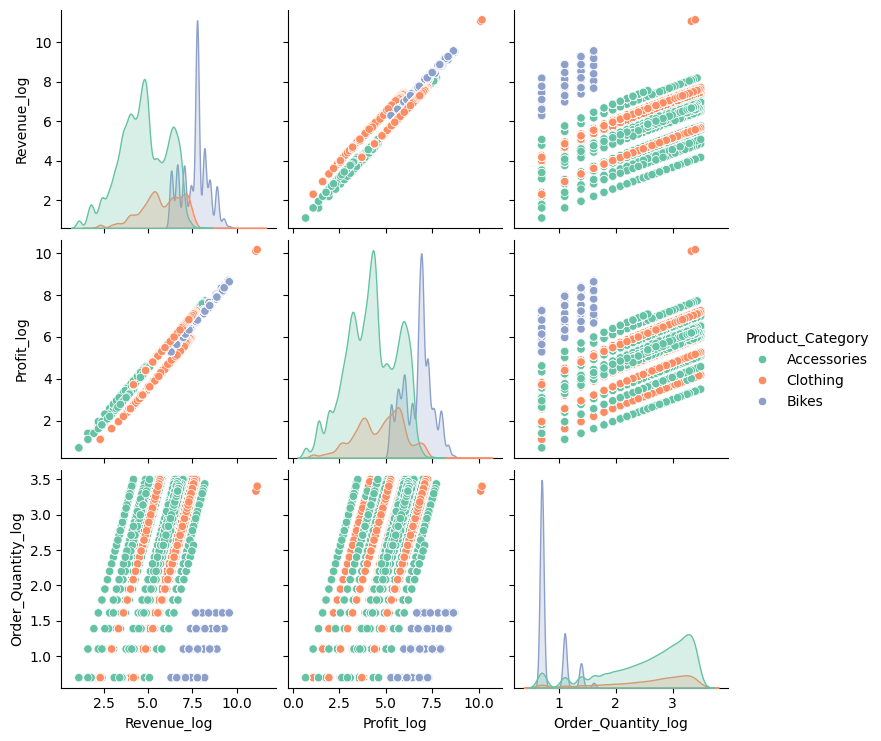

In [6]:
# Histogramas: ver distribuciones
for col in cols_skewed:
    plt.figure(figsize=(6, 4))
    sns.histplot(customers_data[col + "_log"], bins=50, kde=True)
    plt.title(f'Distribución log de {col}')
    plt.show()

# Pairplot log: relaciones entre variables
sns.pairplot(
    customers_data[["Revenue_log", "Profit_log",
                    "Order_Quantity_log", "Product_Category"]],
    hue="Product_Category", palette="Set2"
)
plt.show()


# Agrupación por producto y visualización inicial


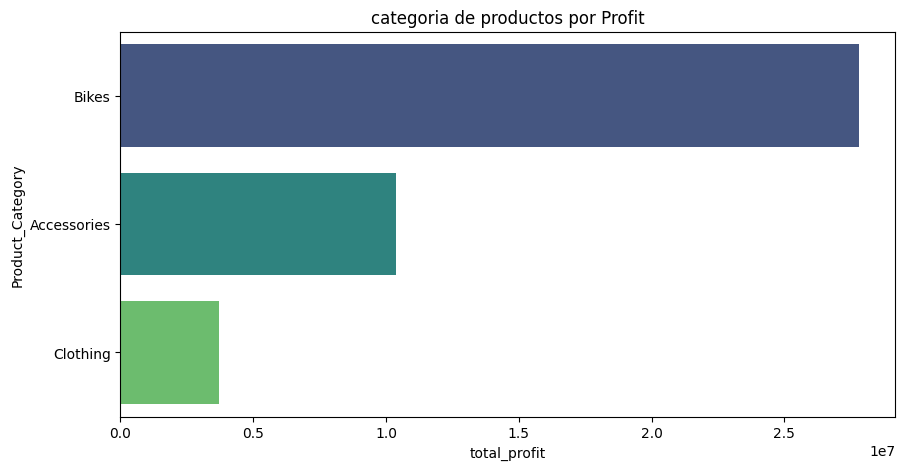

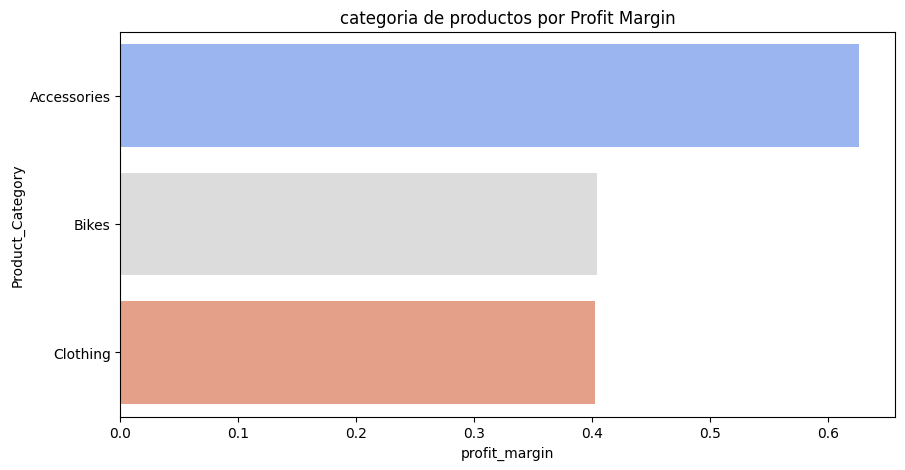

In [7]:
# Agrupados por categoria de productos
product_summary = customers_data.groupby("Product_Category").agg(
    total_revenue=("Revenue", "sum"),
    total_profit=("Profit", "sum"),
    avg_order_quantity=("Order_Quantity", "mean"),
    count_orders=("Order_Quantity", "count")
).reset_index()
product_summary["profit_margin"] = product_summary["total_profit"] / \
    product_summary["total_revenue"]

# Top categoria de productos por profit
plt.figure(figsize=(10, 5))
sns.barplot(
    data=product_summary.sort_values("total_profit", ascending=False),
    x="total_profit", y="Product_Category", hue='Product_Category', palette="viridis"
)
plt.title("categoria de productos por Profit")
plt.show()

# Top productos por margen de ganancia (porcentaje)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=product_summary.sort_values(
        "profit_margin", ascending=False),
    x="profit_margin", y="Product_Category", hue='Product_Category', palette="coolwarm"
)
plt.title("categoria de productos por Profit Margin")
plt.show()

# Clusters

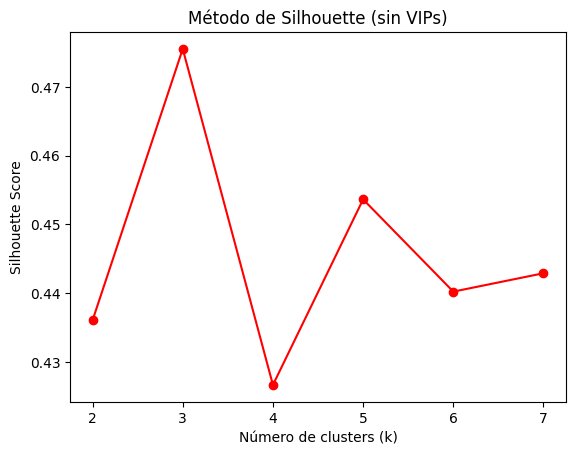

Perfil de clusters (no VIPs):
   Cluster_KMeans  Customer_Age  Order_Quantity        Revenue
0               0     66.590580      371.600000   13652.520000
1               1     36.146351     4230.340426  355445.340426
2               2     29.306158      656.478632   47846.606838

Cantidad de VIPs detectados: 72


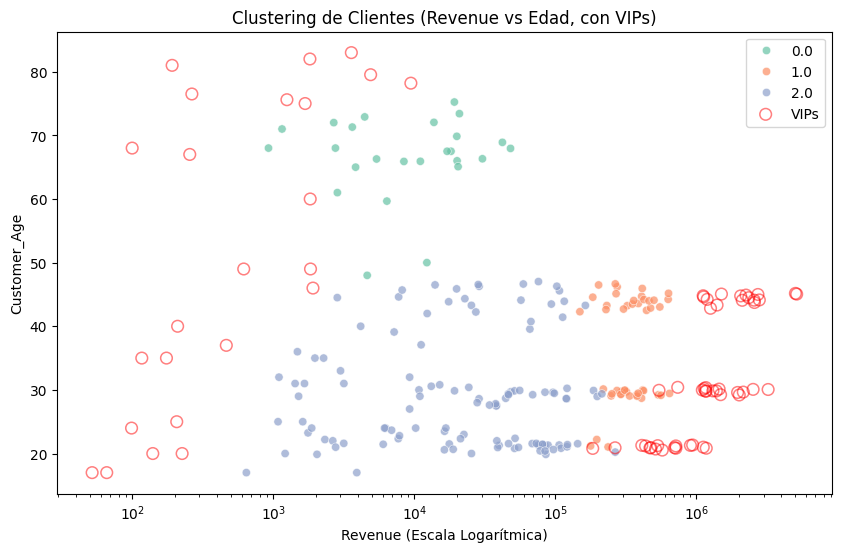

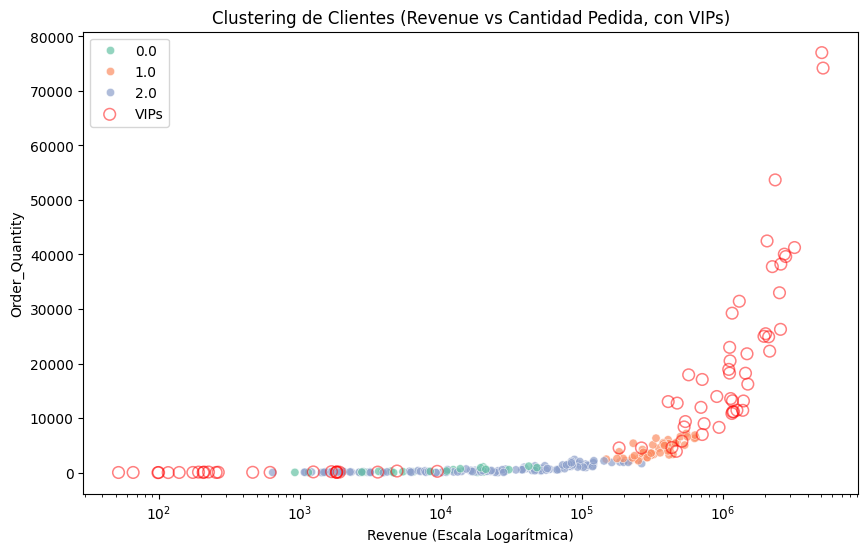

In [8]:
from sklearn.preprocessing import LabelEncoder

customer_summary = customers_data.groupby(
    ['Country', 'State', 'Age_Group', 'Customer_Gender']
).agg({
    'Customer_Age': 'mean',
    'Revenue': 'sum',
    'Profit': 'sum',
    'Order_Quantity': 'sum',
    'Year': ['min','max','count']
}).reset_index()

customer_summary.columns = ['Country','State','Age_Group','Customer_Gender',
                            'Customer_Age','Revenue','Profit','Order_Quantity',
                            'First_Year','Last_Year','Num_Orders']

# Aplicar log1p para corregir las distribuciones asimetricas
for col in ['Revenue', 'Profit', 'Order_Quantity']:
    customer_summary[col + '_log'] = np.log1p(customer_summary[col])


# Detectar VIPs con DBSCAN (detectar outliers)

# Codificar género (M=0, F=1)
le = LabelEncoder()
customer_summary['Gender_Code'] = le.fit_transform(customer_summary['Customer_Gender'])

features_vip = ['Revenue_log', 'Order_Quantity', 'Customer_Age']
X_vip = customer_summary[features_vip]

scaler_vip = RobustScaler()
X_vip_scaled = scaler_vip.fit_transform(X_vip)

dbscan = DBSCAN(eps=0.3, min_samples=8)
customer_summary['Cluster_DBSCAN'] = dbscan.fit_predict(X_vip_scaled)
customer_summary['VIP'] = customer_summary['Cluster_DBSCAN'] == -1


# Clustering con KMeans (sin VIPs)
non_vip_data = customer_summary[~customer_summary['VIP']].copy()

features_kmeans = ['Revenue_log', 'Order_Quantity', 'Customer_Age']
X_kmeans = non_vip_data[features_kmeans]

scaler_kmeans = RobustScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

# Silhouette: evaluar matematicamente num. clusters
silhouette_scores = []
K = range(2, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans_scaled)
    score = silhouette_score(X_kmeans_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K, silhouette_scores, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de Silhouette (sin VIPs)')
plt.show()

# Entrenar con k=3 (mejor comprensión grafica y estrategica)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
non_vip_data['Cluster_KMeans'] = kmeans.fit_predict(X_kmeans_scaled)

# Guardar resultados en el dataset original
customer_summary.loc[non_vip_data.index, 'Cluster_KMeans'] = non_vip_data['Cluster_KMeans']


# Perfiles de clusters + VIPs

cluster_profile = non_vip_data.groupby('Cluster_KMeans').agg({
    'Customer_Age': 'mean',
    'Order_Quantity': 'mean',
    'Revenue': 'mean'
}).reset_index()

print("Perfil de clusters (no VIPs):")
print(cluster_profile)

print("\nCantidad de VIPs detectados:", customer_summary['VIP'].sum())


# Visualización del clustering


# Gráfica: Revenue vs Edad
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=customer_summary,
    x='Revenue',
    y='Customer_Age',
    hue='Cluster_KMeans',
    palette='Set2',
    alpha=0.7
)

# VIPs en rojo con círculos
vip_points = customer_summary[customer_summary['VIP']]
plt.scatter(
    vip_points['Revenue'],
    vip_points['Customer_Age'],
    s=70, facecolors='none',
    edgecolors='red',
    linewidths=1.1,
    label="VIPs",
    alpha=0.5
)

plt.xscale('log')
plt.title('Clustering de Clientes (Revenue vs Edad, con VIPs)')
plt.xlabel('Revenue (Escala Logarítmica)')
plt.legend()
plt.show()


# Gráfica: Revenue vs Order_Quantity
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=customer_summary,
    x='Revenue',
    y='Order_Quantity',
    hue='Cluster_KMeans',
    palette='Set2',
    alpha=0.7
)

# Agregar VIPs en rojo con círculos
vip_points = customer_summary[customer_summary['VIP']]
plt.scatter(
    vip_points['Revenue'],
    vip_points['Order_Quantity'],
    s=70, facecolors='none',
    edgecolors='red',
    linewidths=1.1,
    label="VIPs",
    alpha=0.5
)

plt.xscale('log')
plt.title('Clustering de Clientes (Revenue vs Cantidad Pedida, con VIPs)')
plt.xlabel('Revenue (Escala Logarítmica)')
plt.legend()
plt.show()

# Grafica de las 3 columnas con PCA

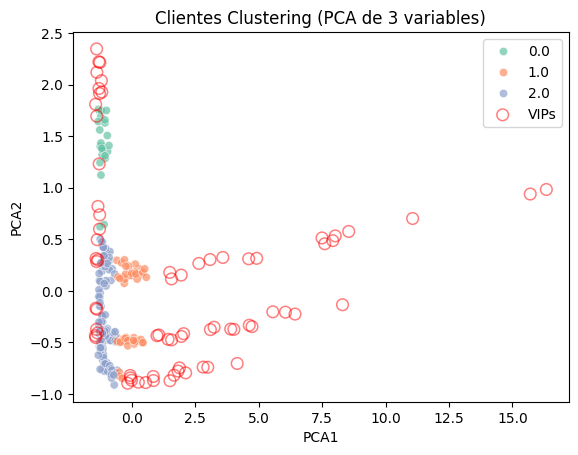

In [9]:
from sklearn.decomposition import PCA

features = ['Revenue_log', 'Order_Quantity', 'Customer_Age']
X = customer_summary[features]
X_scaled = RobustScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

customer_summary['PCA1'] = X_pca[:,0]
customer_summary['PCA2'] = X_pca[:,1]

sns.scatterplot(
    data=customer_summary,
    x='PCA1',
    y='PCA2',
    hue='Cluster_KMeans',
    palette='Set2',
    alpha=0.7
)

# VIPs en rojo
vip_points = customer_summary[customer_summary['VIP']]
plt.scatter(
    vip_points['PCA1'],
    vip_points['PCA2'],
    s=70, facecolors='none',
    edgecolors='red',
    linewidths=1.1,
    label="VIPs",
    alpha=0.5
)

plt.title('Clientes Clustering (PCA de 3 variables)')
plt.legend()
plt.show()


# Graficas para informe tecnico

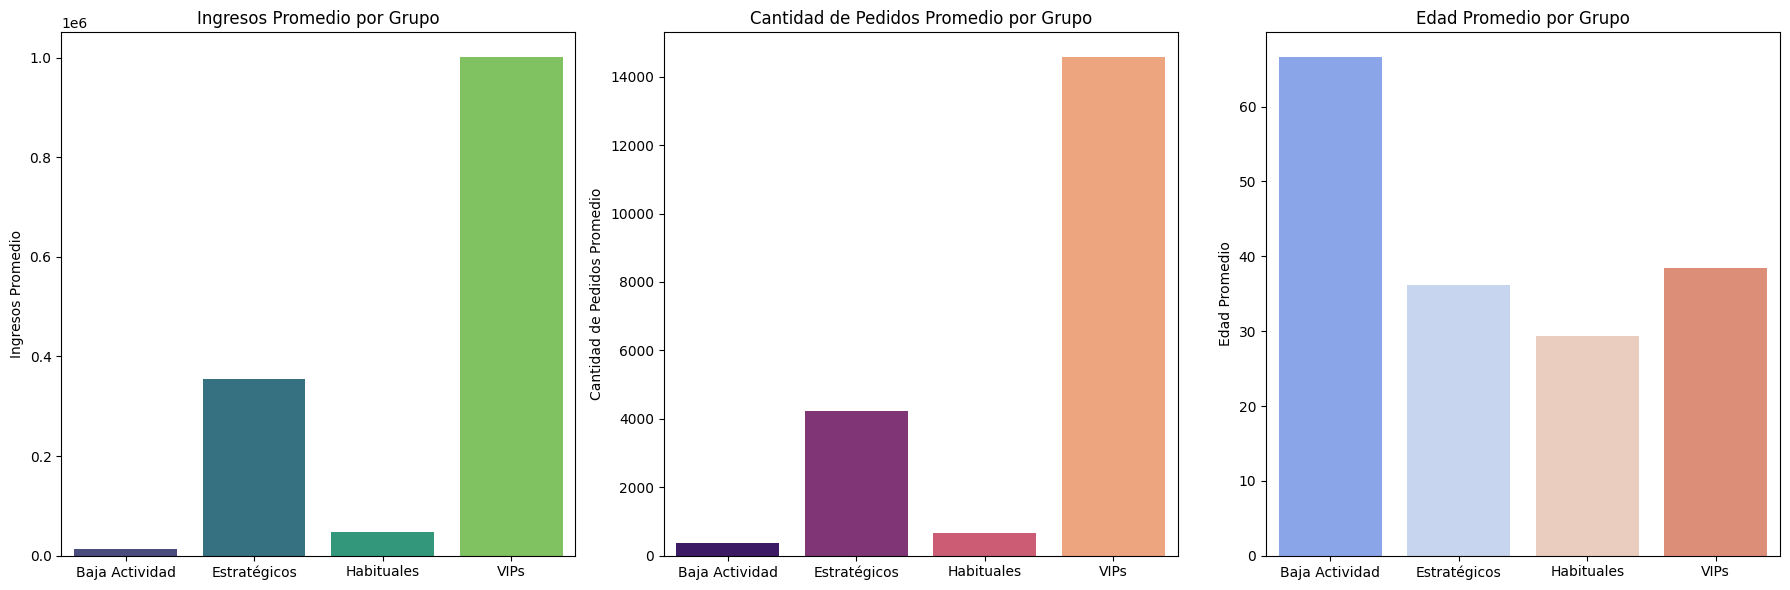

In [10]:
# Perfil de los clústeres no-VIP
cluster_profile_kmeans = non_vip_data.groupby('Cluster_KMeans').agg({
    'Customer_Age': 'mean',
    'Order_Quantity': 'mean',
    'Revenue': 'mean'
}).reset_index()

# Añadir perfil de los VIPs
vip_profile = customer_summary[customer_summary['VIP']].agg({
    'Customer_Age': 'mean',
    'Order_Quantity': 'mean',
    'Revenue': 'mean'
}).to_frame().T

vip_profile['Cluster_KMeans'] = 'VIPs'
profile_df = pd.concat([cluster_profile_kmeans, vip_profile], ignore_index=True)

# Mapear nombres de clusters para mayor claridad
cluster_names = {0.0: 'Baja Actividad', 1.0: 'Estratégicos', 2.0: 'Habituales', 'VIPs': 'VIPs'}
profile_df['Cluster_Name'] = profile_df['Cluster_KMeans'].map(cluster_names)

# Visualizar el perfil de los clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Cluster_Name', y='Revenue', data=profile_df, ax=axes[0], palette='viridis', hue='Cluster_Name')
axes[0].set_title('Ingresos Promedio por Grupo')
axes[0].set_ylabel('Ingresos Promedio')
axes[0].set_xlabel('')

sns.barplot(x='Cluster_Name', y='Order_Quantity', data=profile_df, ax=axes[1], palette='magma', hue='Cluster_Name')
axes[1].set_title('Cantidad de Pedidos Promedio por Grupo')
axes[1].set_ylabel('Cantidad de Pedidos Promedio')
axes[1].set_xlabel('')

sns.barplot(x='Cluster_Name', y='Customer_Age', data=profile_df, ax=axes[2], palette='coolwarm', hue='Cluster_Name')
axes[2].set_title('Edad Promedio por Grupo')
axes[2].set_ylabel('Edad Promedio')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()